# 04 — Transformer Model (DistilBERT)
**Employee Feedback Intelligence Platform**

Fine-tunes `distilbert-base-uncased` using the HuggingFace `Trainer` API — no manual PyTorch training loop needed.

1. Load & sample cleaned data
2. Encode labels
3. Train / Val / Test split (70/15/15)
4. Tokenise with `DistilBertTokenizerFast`
5. Build HuggingFace `Dataset` objects
6. Fine-tune with `Trainer`
7. Training curves
8. Evaluate on test set
9. Confusion matrix & error analysis
10. Save model → `models/transformer/`

## 0. Imports & Config

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
import torch
from datasets import Dataset
from transformers import (
    DistilBertTokenizerFast,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
import transformers, datasets, accelerate

warnings.filterwarnings('ignore')

print('Transformers :', transformers.__version__)
print('Datasets     :', datasets.__version__)
print('Accelerate   :', accelerate.__version__)
print('Torch        :', torch.__version__)
print('GPU available:', torch.cuda.is_available())

Transformers : 5.0.0
Datasets     : 4.8.5
Accelerate   : 1.13.0
Torch        : 2.10.0+cu128
GPU available: True


In [2]:
# ── Hyper-parameters & constants ──────────────────────────────────────
MODEL_NAME   = 'distilbert-base-uncased'
MAX_LEN      = 128
BATCH_SIZE   = 32
EPOCHS       = 4
LR           = 2e-5
WEIGHT_DECAY = 0.01
SAMPLE_SIZE  = 3000   # total rows (stratified across 3 classes)
RANDOM_STATE = 42

LABEL2ID = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

In [3]:
df = pd.read_csv('/kaggle/input/datasets/nouranmousa/cleaned-csv/cleaned.csv')
print(f'Full dataset : {len(df):,} rows')

df = df.dropna(subset=['text', 'sentiment'])
df = df.groupby('sentiment', group_keys=False).apply(
    lambda g: g.sample(min(len(g), SAMPLE_SIZE // 3), random_state=RANDOM_STATE)
).reset_index(drop=True)

print(f'Working sample: {len(df):,} rows')
print(df['sentiment'].value_counts())

Full dataset : 805,051 rows
Working sample: 3,000 rows
sentiment
Negative    1000
Neutral     1000
Positive    1000
Name: count, dtype: int64


## 2. Encode Labels

In [4]:
df['label'] = df['sentiment'].map(LABEL2ID)
print('Label mapping:', LABEL2ID)
print(df[['sentiment', 'label']].drop_duplicates().sort_values('label'))

Label mapping: {'Negative': 0, 'Neutral': 1, 'Positive': 2}
     sentiment  label
0     Negative      0
1000   Neutral      1
2000  Positive      2


## 3. Train / Val / Test Split  (70 / 15 / 15)

In [5]:
X = df['text'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15 / 0.85,
    random_state=RANDOM_STATE, stratify=y_train
)

print(f'Train : {len(X_train):,}')
print(f'Val   : {len(X_val):,}')
print(f'Test  : {len(X_test):,}')

Train : 2,099
Val   : 451
Test  : 450


## 4. Tokenize

In [6]:
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=MAX_LEN,
        padding=False,   # DataCollatorWithPadding pads each batch dynamically
    )

print('Tokenizer loaded:', MODEL_NAME)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: distilbert-base-uncased


## 5.Dataset & DataLoaders

In [7]:
from transformers import DataCollatorWithPadding

def make_hf_dataset(texts, labels):
    """Wrap numpy arrays in a HuggingFace Dataset and tokenise."""
    ds = Dataset.from_dict({'text': list(texts), 'label': list(labels)})
    ds = ds.map(tokenize_fn, batched=True, remove_columns=['text'])
    ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
    return ds

print('Building datasets...')
train_ds = make_hf_dataset(X_train, y_train)
val_ds   = make_hf_dataset(X_val,   y_val)
test_ds  = make_hf_dataset(X_test,  y_test)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(f'Train examples : {len(train_ds):,}')
print(f'Val   examples : {len(val_ds):,}')
print(f'Test  examples : {len(test_ds):,}')
print('Sample features:', train_ds.features)

Building datasets...


Map:   0%|          | 0/2099 [00:00<?, ? examples/s]

Map:   0%|          | 0/451 [00:00<?, ? examples/s]

Map:   0%|          | 0/450 [00:00<?, ? examples/s]

Train examples : 2,099
Val   examples : 451
Test  examples : 450
Sample features: {'label': Value('int64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}


## 6. Load Pretrained DistilBERT

In [8]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)
print(f'Model loaded on {device}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on cuda
Parameters: 66,955,779


## 7. Metrics & Training


In [9]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
    }

In [ ]:
training_args = TrainingArguments(
    output_dir='../models/transformer',
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=4,
    learning_rate=LR,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=0.1,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    logging_steps=50,
    report_to='none',
    seed=RANDOM_STATE,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print('Trainer ready')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer ready


## 8. Fine-Tune

In [11]:
train_result = trainer.train()
print('Training complete')
print(train_result.metrics)

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,2.150396,0.441242,0.416894
2,No log,2.078400,0.523282,0.513456
3,No log,2.011724,0.552106,0.536713
4,No log,1.983853,0.543237,0.529552


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Training complete
{'train_runtime': 55.2788, 'train_samples_per_second': 151.885, 'train_steps_per_second': 0.651, 'total_flos': 278054028389376.0, 'train_loss': 7.648876614040798, 'epoch': 4.0}


## 9. Training Curves

In [13]:
# Extract per-epoch metrics from trainer log history
log_history = trainer.state.log_history

epochs_data = []
for entry in log_history:
    if 'eval_accuracy' in entry:
        epoch_num = entry.get('epoch', None)
        # Find matching train_loss for this epoch
        train_loss = next(
            (e['loss'] for e in log_history
             if 'loss' in e and abs(e.get('epoch', -1) - epoch_num) < 0.05),
            None,
        )
        epochs_data.append({
            'epoch'     : epoch_num,
            'train_loss': train_loss,
            'val_acc'   : entry['eval_accuracy'],
            'val_f1'    : entry['eval_f1_macro'],
        })

hist_df = pd.DataFrame(epochs_data)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=hist_df['epoch'], y=hist_df['train_loss'],
    mode='lines+markers', name='Train Loss', yaxis='y2',
    line=dict(color='#ef4444'),
))
fig.add_trace(go.Scatter(
    x=hist_df['epoch'], y=hist_df['val_acc'],
    mode='lines+markers', name='Val Accuracy',
    line=dict(color='#6366f1'),
))
fig.add_trace(go.Scatter(
    x=hist_df['epoch'], y=hist_df['val_f1'],
    mode='lines+markers', name='Val Macro-F1',
    line=dict(color='#22c55e'),
))
fig.update_layout(
    title='DistilBERT Fine-Tuning Curves (HuggingFace Trainer)',
    xaxis_title='Epoch',
    yaxis=dict(title='Score', range=[0, 1]),
    yaxis2=dict(title='Loss', overlaying='y', side='right'),
    legend=dict(x=0.01, y=0.01),
)
fig.show()

## 10. Evaluate on Test Set

In [14]:
predictions = trainer.predict(test_ds)
y_pred = np.argmax(predictions.predictions, axis=1)

y_pred_str = [ID2LABEL[p] for p in y_pred]
y_true_str = [ID2LABEL[l] for l in y_test]

acc_test = accuracy_score(y_true_str, y_pred_str)
f1_test  = f1_score(y_true_str, y_pred_str, average='macro')

print(f'Test Accuracy : {acc_test:.4f}')
print(f'Test Macro-F1 : {f1_test:.4f}')
print()
print(classification_report(y_true_str, y_pred_str))

Test Accuracy : 0.5200
Test Macro-F1 : 0.5051

              precision    recall  f1-score   support

    Negative       0.58      0.63      0.60       150
     Neutral       0.42      0.27      0.33       150
    Positive       0.52      0.66      0.58       150

    accuracy                           0.52       450
   macro avg       0.51      0.52      0.51       450
weighted avg       0.51      0.52      0.51       450



## 11. Confusion Matrix

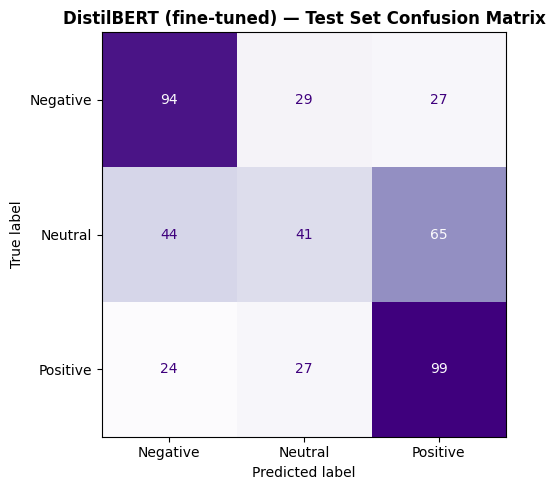

Saved assets/transformer_confusion_matrix.png


In [15]:
labels_order = ['Negative', 'Neutral', 'Positive']
cm = confusion_matrix(y_true_str, y_pred_str, labels=labels_order)

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(cm, display_labels=labels_order).plot(
    ax=ax, colorbar=False, cmap='Purples'
)
ax.set_title('DistilBERT (fine-tuned) — Test Set Confusion Matrix', fontweight='bold')
plt.tight_layout()
os.makedirs('../assets', exist_ok=True)
plt.savefig('../assets/transformer_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved assets/transformer_confusion_matrix.png')

## 12. Save Model Checkpoint & Metrics

In [17]:
save_path = '/kaggle/working/models/transformer'
os.makedirs(save_path, exist_ok=True)

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

metrics = {
    'model'         : f'{MODEL_NAME} (fine-tuned, PyTorch + HuggingFace Trainer)',
    'sample_size'   : SAMPLE_SIZE,
    'epochs_trained': len(hist_df),
    'test_accuracy' : round(float(acc_test), 4),
    'test_macro_f1' : round(float(f1_test),  4),
    'history'       : hist_df.to_dict(orient='records'),
}
with open('/kaggle/working/models/transformer_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(f'Model saved  to {save_path}/')
print('Metrics saved to /kaggle/working/models/transformer_metrics.json')
print(f"Reload: AutoModelForSequenceClassification.from_pretrained('{save_path}')")
print('Ready for Notebook 05 — Model Comparison')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved  to /kaggle/working/models/transformer/
Metrics saved to /kaggle/working/models/transformer_metrics.json
Reload: AutoModelForSequenceClassification.from_pretrained('/kaggle/working/models/transformer')
Ready for Notebook 05 — Model Comparison
